In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os


In [29]:
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rc('font', family=font_name)
else:
    plt.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

In [32]:
best_path = "../data/raw/aladin_books_bestseller.csv"

In [33]:
df = pd.read_csv(best_path)

### 텍스트 길이 분석

In [34]:
df['desc_len'] = df['description'].fillna('').str.len()
df['title_len'] = df['title'].str.len()

/tmp/ipykernel_30098/448318439.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


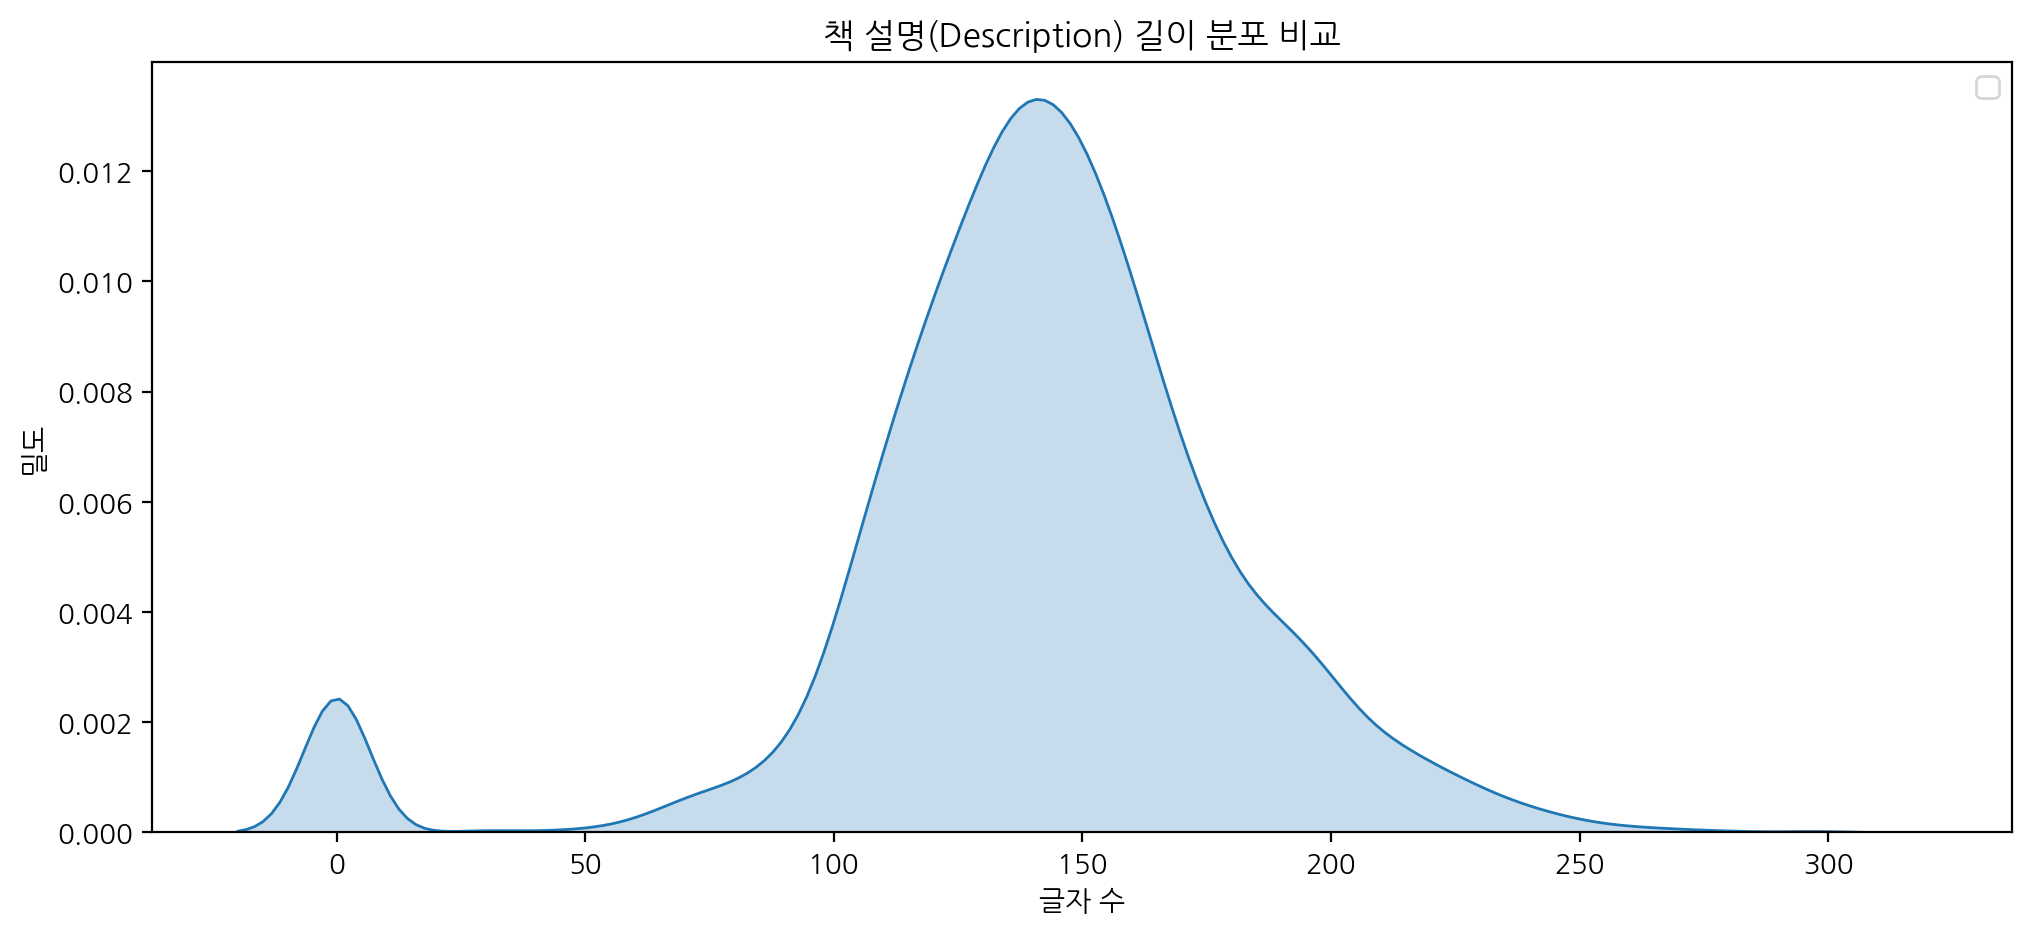

In [35]:
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df, x='desc_len', fill=True)
plt.title("책 설명(Description) 길이 분포 비교")
plt.xlabel("글자 수")
plt.ylabel("밀도")
plt.legend()
plt.show()

### 평점

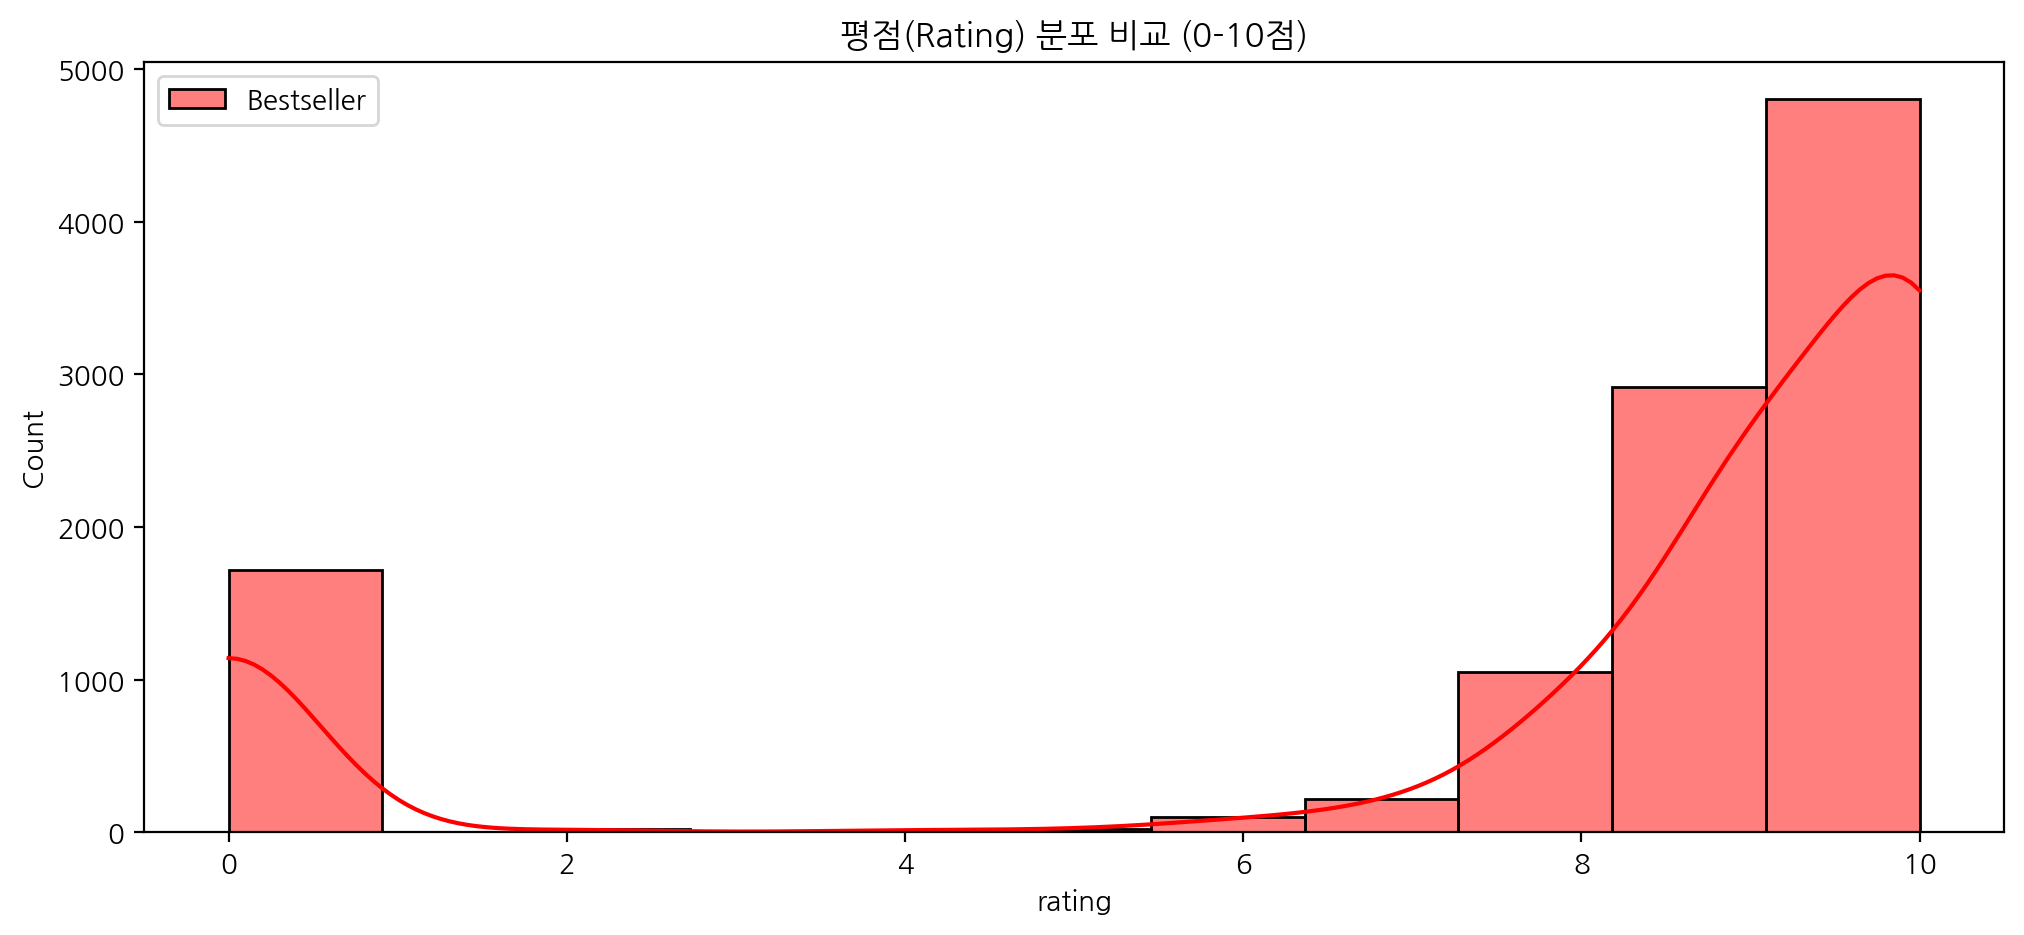

In [36]:
plt.figure(figsize=(12, 5))
# 0점(평가없음)을 제외하고 분석하거나 포함해서 비교
sns.histplot(data=df, x='rating', bins=11, label='Bestseller', kde=True, color='red', alpha=0.5)
plt.title("평점(Rating) 분포 비교 (0-10점)")
plt.legend()
plt.show()

### 주요 통계치 비교

In [37]:
stats = []
stats.append({
    "Dataset": name,
    "Total Count": len(df),
    "Desc Mean Len": df['desc_len'].mean(),
    "Desc Median Len": df['desc_len'].median(),
    "Rating Mean": df[df['rating'] > 0]['rating'].mean(), # 0점 제외 평균
    "Rating Median": df[df['rating'] > 0]['rating'].median(),
    "Missing Desc %": (df['description'].isna().sum() / len(df)) * 100
})

df_stats = pd.DataFrame(stats)
display(df_stats)

,Dataset,Total Count,Desc Mean Len,Desc Median Len,Rating Mean,Rating Median,Missing Desc %
0,Bestseller,10881,140.471188,142.0,9.291517,10.0,4.071317
